<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Classical Statistics: Hypothesis Testing <a class="tocSkip">

In this notebook we will learn about **statistical inference**, the process of making decisions based on observational data. In science, these decisions are often related to theoretical models.

> **Theories** are potential **models** describing how nature works.

> **Observations** are measurements of the properties of natural objects.

To learn something new about the Universe we need to find ways to answer questions such as:
- Does our new theory agree with the data (hypothesis testing)?
- What are the parameters of an existing theory (parameter estimation) calibrated on observational data?
- Which theory is more probable (model comparison, see lecture on Bayesian statistics)?

# Setup

In [1]:
import numpy as np
import scipy.stats as st
import requests

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Working in:
/content/astrostat-school-8/Hypothesis_Testing

Content:
	 ['Hypothesis_Testing.ipynb', 'creating_fig2', 'data', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# 1. Hypothesis testing

**Definition**

Hypothesis testing is the process of testing an assumption regarding a parameter of a population, using a sample from the latter.

For example: the mass of globular clusters follows a normal distribution.

**Testing the value of a parameter...**

...means that we need to quantify the probability (density) of the parameter using a **statistic** calculated on the sample.

For example, the mean of the globular cluster mass distribution is equal to $3.2\times 10^5 M_\odot$.


## 1.1 Example: the sum of two independently and identically-distributed normal variables

Let's assume that we have two data points with values $x$ and $y$, coming from the same normal distribution $N(\mu,\sigma)$, consequently:

$$\Large P_X(x) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp \left[-\frac{\left(x-\mu\right)^2}{2\sigma^2}\right]$$

$$\Large P_Y(y) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp \left[-\frac{\left(y-\mu\right)^2}{2\sigma^2}\right]$$

What is the probability density function of their sum, $z = x + y$ as a function of the data distribution parameters, $\mu$ and $\sigma$?


### Any thoughts?

$$\Large P_Z(z) = Prob(x+y=z) = Prob(x=0, y=z) + Prob(x=0.1, y=z-0.1) + ... $$

so...

$$\Large P_Z(z) = \int\limits_{-\infty}^{\infty} P_X(x) P_Y(z-x) \; dx
=   \int\limits_{-\infty}^{\infty}
    \frac{1}{\sqrt{2\pi \sigma^2}} \exp \left[-\frac{\left(x-\mu\right)^2}{2\sigma^2}\right]
    \frac{1}{\sqrt{2\pi \sigma^2}} \exp \left[-\frac{\left(z-x-\mu\right)^2}{2\sigma^2}\right]
     \; dx
$$

(...after one page of math...)

$$\Large P_Z(z) = \frac{1}{\sqrt{4\pi \sigma^2}} \exp\left[-\frac{\left(z-2\mu\right)^2}{4\sigma^2}\right] $$

Does it seem familiar? If we use $\sigma' = \sqrt{2} \sigma$...

$$\Large P_Z(z) = \frac{1}{\sqrt{2\pi \sigma'^2}} \exp\left[-\frac{\left(z-2\mu\right)^2}{2\sigma'^2}\right] $$

...so it's a normal distribution peaking at $2\mu$, with a standard deviation $\sqrt{2}$ times **higher** than that of the data distribution!


### Using the resulting distribution

Having quantified the probability density of the statistic (the sum of two random numbers), we can test how probable is the sum of two data points, or what is the probability of it being less or more than a specific value (e.g., 0).

Let's assume that the underlying distribution of $x$ and $y$ is $\mathcal{N}(3.5, 1)$... this is our **model** leading to the prediction that the sum will be distributed as $\mathcal{N}(7, \sqrt{2})$.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:**  Select the number of samples to be drawn from each of the two initial distributions.

</div>

Two values from the data distribution: [3.97321507 4.31672255]


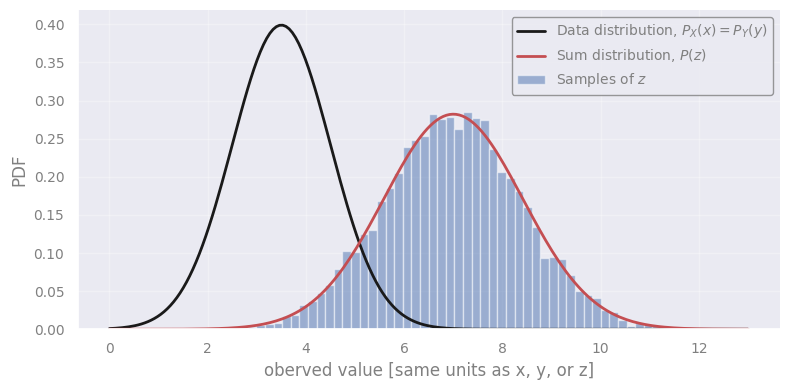

In [3]:
# defining the distribution of X and Y
data_mean = 3.5
data_std = 1.0
data_dist = st.norm(data_mean, data_std)
print("Two values from the data distribution:", data_dist.rvs(size=2))

# taking pairs of samples from the distribution, and summing them
n_samples = 10000
sum_sample = data_dist.rvs(size=(n_samples, 2)).sum(axis=1)

# the theoretically-expected distribution of the sum
sum_dist = st.norm(2 * data_mean, np.sqrt(2.0) * data_std)

# plotting
xx = np.linspace(0.0, 13.0, 200)
plt.figure()
plt.plot(xx, data_dist.pdf(xx), "k-", label="Data distribution, $P_X(x)=P_Y(y)$")
plt.plot(xx, sum_dist.pdf(xx), "r-", label="Sum distribution, $P(z)$")
plt.hist(sum_sample, bins="fd", density=True, alpha=0.5, label="Samples of $z$")
plt.legend(loc="upper right")
plt.xlabel('oberved value [same units as x, y, or z]')
plt.ylabel('PDF')
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: knowing the distribution of X and Y, would observing a sum ($z$) equal to 4 surprise you?</b>
<br>  
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

From the above experiment we see that there are samples of the sum close to $4$. However, most of the samples are at higher values... so it's a little bit surprising. We would expect the sum of 4 to arise if the distributions had smaller mean (rather than 3.5), or at least higher standard deviation (rather than 1).

</details>

</div>

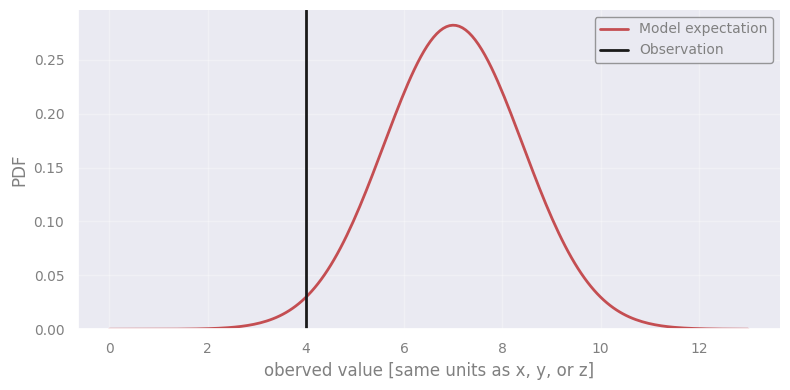

In [4]:
xx = np.linspace(0.0, 13.0, 200)
plt.figure()
plt.plot(xx, sum_dist.pdf(xx), "r-", label="Model expectation")
plt.axvline(4.0, color="k", label="Observation")
plt.legend(loc="upper right")
plt.ylim(ymin=0.0)
plt.xlabel('oberved value [same units as x, y, or z]')
plt.ylabel('PDF')
plt.show()

## 1.2 Population vs Sample

A short description of what we mean by *population* and *sample* will be helpful at this point.

*Population*: All members of a specified group, e.g. all the star clusters in the Milky Way, all the spiral galaxies in the Universe, etc.

*Sample*: A subset of varying size coming from the population, e.g. all the known star clusters, all the spiral galaxies observed by Euclid in a specific $1\times 1$ arcmin area of the sky.

Clearly, it is impractical to measure all the members of a population. Usually, we proceed by accepting that some property of the population is true (a distribution, a mean, a specific parameter, etc) and then try to show whether this (the "truth" or the "theory") is supported by the data. The data in most cases represent a subset of the population, i.e. a sample. Here, we will test our theories (null hypothesis) by computing a statistic from the sample and comparing it to the population.

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Hypothesis_Testing/images/population_vs_sample.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<p style="text-align: center; font-size: 0.9em; color: gray;">
        Figure 1. A sample is a subset of a population. A more detailed and compact explanation can be found at the following link: <a href="https://www.geeksforgeeks.org/machine-learning/population-and-sample-statistics/" target="_blank">https://www.geeksforgeeks.org/machine-learning/population-and-sample-statistics/</a>
</p>

# 2. Verifying a model for the mass of globular clusters (GC)

## 2.1 The data

A research team has studied a sample of globular clusters and measured their masses. Let's load and plot their histogram.

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_811/2597679792.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\log M [M_\odot]$")


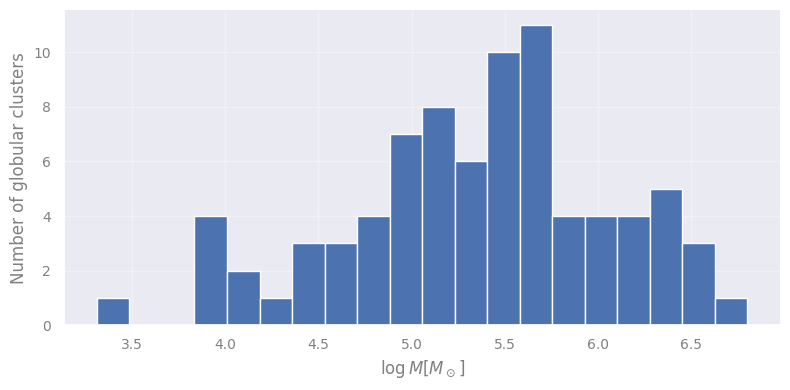

In [5]:
masses = np.genfromtxt("data/GC_MWG_masses.csv")
log_masses = np.log10(masses)

plt.figure()
plt.hist(log_masses, bins=20)
plt.xlabel("$\log M [M_\odot]$")
plt.ylabel("Number of globular clusters")
plt.show()

## 2.2 The theoretical model

Globis & Clusterton (2022) used hydrodynamical galaxy simulations to model the formation of globular clusters (GC) in a galaxy like the Milky Way. They found that the masses of the synthetic GCs are described by a log-normal distribution. Namely, the decimal logarithm of the masses is normally distributed:

$$\Large \log_{10} \left(\frac{M}{M_\odot}\right) \sim \mathcal{N}(5.5, 1) $$

meaning that the GCs masses peak at $10^{5.5} M_\odot \simeq 3.2\times 10^5 M_\odot$ and the typical scatter is $1\,\mathrm{dex}$ (one order of magnitude).

Let's see this the model along with the data...

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:**  Select the appropriate distribution from scipy.stats: https://docs.scipy.org/doc/scipy/reference/stats.html

</div>

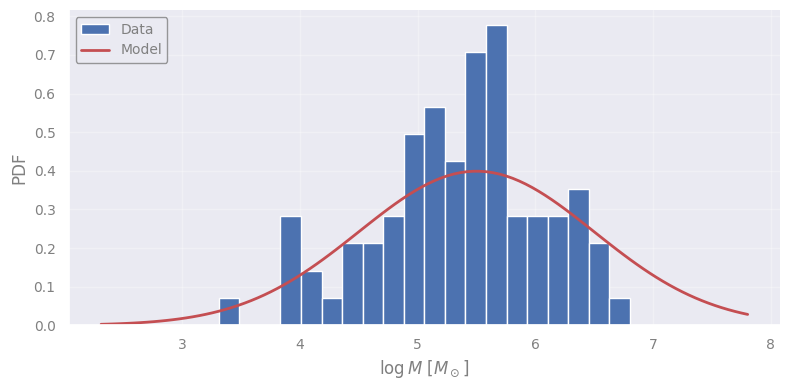

In [11]:
model_mean = 5.5
model_std = 1.0

logm_for_plot = np.linspace(min(log_masses)-1, max(log_masses)+1, 100)
model_prob_for_plot = st.norm(model_mean, model_std).pdf(logm_for_plot)

plt.figure()
plt.hist(log_masses, bins=20, density=True, label="Data")
plt.plot(logm_for_plot, model_prob_for_plot, "r-", lw=2, label="Model")
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF")
plt.legend(loc="upper left")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: do you think that the model is justified by the above observations?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

This is subjective. However, it's not obviously mismatched. Perhaps with more observations we could make a better decision.

</details>

</div>

## 2.3 Using the sample mean as a statistic

In [9]:
sample_mean = np.mean(log_masses)
sample_std = np.std(log_masses)

print(f"MODEL:  Mean = {model_mean:.2f} | Std = {model_std:.2f}")
print(f"SAMPLE: Mean = {sample_mean:.2f} | Std = {sample_std:.2f}")

MODEL:  Mean = 5.50 | Std = 1.00
SAMPLE: Mean = 5.35 | Std = 0.72


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: is the sample mean close to the model's value?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

There is no right answer... it is subjective. Our goal here is to quantify this "subjectiveness"!

</details>

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: does the standard deviation give a sense of how close the mean values are?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Not exactly. The standard deviation describes the scatter of the data. In itself, it does not say much about the deviation of the sample mean from the model's expectation.

</details>

</div>

## 2.4 Standard error of the mean

Whether the mean of the sample is close to the mean of the model depends on the sample size. The larger the sample size, the more accurate our estimate of the mean. As we increase the size we would expect the mean to converge to the mean of the model (and that of the underlying population, if the model is correct).

For normally distributed data the **standard deviation of the mean** scales as:

$$ \Large \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}} $$

where $\sigma$ is the population standard deviation and $N$ is the sample size.

In most cases, the standard deviation of the population is unknown. For this reason, we use the same sample to estimate it, calculating the *sample standard deviation*, $s$. The standard deviation of the sample mean is called **standard error on the mean**:

$$ \Large s_{\bar{x}} = \frac{s}{\sqrt{N}} $$

The sample mean is considered to be normally distributed (see *Central Limit Theorem* below), and therefore we can calculate the number of standard errors the theoretical value is away from the sample mean, or the **sigmas**.

Standard error of the mean = 0.08
Sigma's of difference      : 1.80


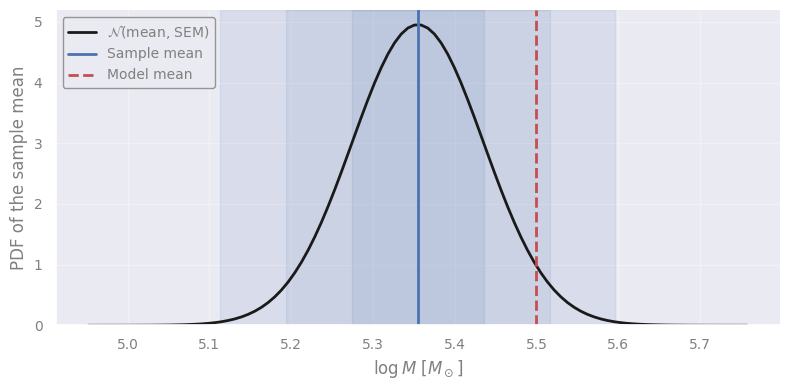

In [10]:
# computing the standard error of the mean, and the difference in terms of sigmas from the model mean
sample_sem = st.sem(log_masses)
print(f"Standard error of the mean = {sample_sem:.2f}")
print(f"Sigma's of difference      : {(model_mean-sample_mean) / sample_sem:.2f}")

x_plot = np.linspace(sample_mean - 5 * sample_sem, sample_mean + 5 * sample_sem, 100)

# the distribution of the sample mean (using the measured value and the standard error of the mean)
mean_distribution = st.norm(sample_mean, sample_sem)

# plotting
y_plot = mean_distribution.pdf(x_plot)
plt.figure()
plt.plot(x_plot, y_plot, "k-", lw=2, label=r"$\mathcal{N}$(mean, SEM)")
plt.axvline(sample_mean, ls="-", color="b", label="Sample mean")
plt.axvline(model_mean, ls="--", lw=2, color="r", label="Model mean")
for sigmas in [1, 2, 3]:
    plt.axvspan(sample_mean - sigmas*sample_sem, sample_mean + sigmas*sample_sem, color="b", alpha=0.1)
plt.legend(loc="upper left")
plt.ylim(ymin=0.0)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF of the sample mean")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: is the means' difference small enough to accept the model?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Still subjective! But we are closer to quantifying this "subjectiveness"!

</details>

</div>

## 2.5 When to reject a model...

One might argue that if the theoretical mean is too extreme, either **too low** or **too high** compared to the sample mean, then we should **reject the hypothesis that the model describes the data at hand**.

We can actually calculate from the sample mean distribution what is the probability of such extreme values.

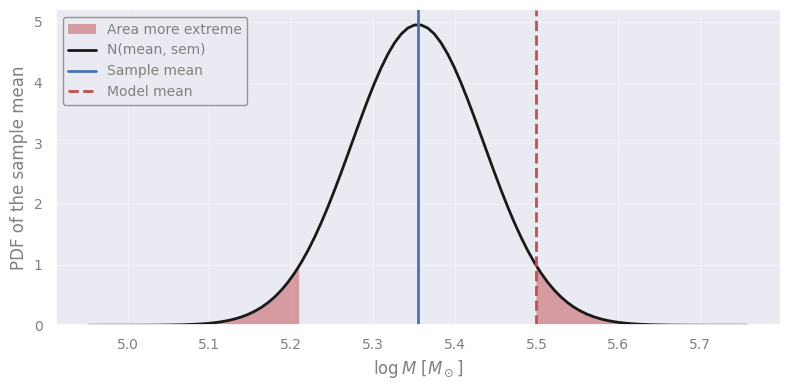

In [12]:
x_plot = np.linspace(sample_mean - 5 * sample_sem, sample_mean + 5 * sample_sem, 100)

diff = abs(sample_mean - model_mean)
xx_before = np.linspace(sample_mean - 5 * sample_sem, sample_mean - diff, 100)
xx_after = np.linspace(sample_mean + diff, sample_mean + 5 * sample_sem, 100)

mean_distribution = st.norm(sample_mean, sample_sem)
y_plot = mean_distribution.pdf(x_plot)

plt.figure()
plt.fill_between(xx_before, mean_distribution.pdf(xx_before), 0, color="r", ec="none", alpha=0.5, label="Area more extreme")
plt.fill_between(xx_after, mean_distribution.pdf(xx_after), 0, color="r", ec="none", alpha=0.5)
plt.plot(x_plot, y_plot, "k-", lw=2, label="N(mean, sem)")
plt.axvline(sample_mean, ls="-", color="b", label="Sample mean")
plt.axvline(model_mean, ls="--", lw=2, color="r", label="Model mean")
plt.legend(loc="upper left")
plt.ylim(ymin=0.0)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF of the sample mean")
plt.show()

The cumulative distribution function is

$$ \Large F(x) = \int\limits_{-\infty}^{x} f(x') dx' $$

The "area more exteme" is

$$
\begin{aligned}
\Large p   
    &= \Large 1 - \textrm{(area between)} = \\
    &= \Large 1 - \int\limits_{m-d}^{m+d} f(x') dx' = \\
    &= \Large 1 - \left(\int\limits_{-\infty}^{m+d} f(x')dx' - \int\limits_{-\infty}^{m-d} f(x')dx' \right) = \\
    &= \Large 1 - \left[F(m+d) - F(m-d)\right]
\end{aligned}
$$

where $m$ is the sample mean, and $d$ is its absolute distance from the model's mean.

In our case, we have...

In [13]:
area_more_extreme = 1 - (mean_distribution.cdf(sample_mean+diff) - mean_distribution.cdf(sample_mean-diff))
print(f"Area more extreme, p = {area_more_extreme:.4f}")

Area more extreme, p = 0.0716


Using the correct words is crucial here: This is the **probability of being wrong if we reject the model**! So, the smaller this number, the more safely we can reject the model.

We find a $\sim 7\%$ probability, or **$p$-value** 0.07, of being wrong if we reject this model. *Can we risk it*? It is **our choice** to consider our "threshold" or **significance level**!

If we had decided **before looking at the data** to use a 5% threshold, then our conclusion would be:

> *we do not reject the model, with a significance level of 5%", or equivalently, we have a 5% probability of being wrong in rejecting the model.*

#### IMPORTANT: we didn't accept the model
The analysis above does not validate the model! The only thing we verified is that **one property**, the mean value of the sample, is not too different than what we would expect from the model. If it was, then we would have reasons to believe that this model is incorrect. For example, if we had found $p=0.0001$ we would **reject the model** given the sample at hand ($0.01\%$ chance of being wrong in doing so).

In Science, we can only disprove theories, never prove them (see Karl Popper's work on philosophy of science). For example, a theory postulates that "all swans are white" - in order to confirm it, one needs to observe all swans in existence, but finding just one swan of different color is enough to disprove it.

> "It doesn't matter how beautiful your theory is, it doesn't matter how smart you are. If it doesn't agree with the experiment, it's wrong." --- Richard Feynmann


#### IMPORTANT: 100-7=93% is not the probablity for the hypothesis (or model) to be correct
There are infinite other models under which the $p$-value would be above our threshold, for example, $N(5.5, 0.101)$, $N(5.51, 0.1)$, ...

> "Whenever a theory appears to you as the only possible one, take this as a sign that you have neither understood the theory nor the problem which it was intended to solve." --- Karl Popper


### Choosing the significance level

There is no rule on what the significance level should be. Just that it should be decided before looking at the data. This is important in order to avoid **biasing our conclusions by relaxing our criteria for models that we like, or making it harder for models that we don't like**, a typical behaviour often displayed by humans without realizing it.

In Astronomy, $2 + 2 \simeq 5$, so we often use 0.5, 1 or 5%. In Nuclear Physics and precision experiments often $10^{-7}$ or $10^{-10}$ are used!

Since the $p$-value is connected to the number of sigmas in difference, often we refer to *sigmas* instead of a significance level. It is shorter to say and easier to visualize in plots with error bars and distributions. For example:

| Sigmas | Probability (inside) | Probability (outside) |
| --- | --- | --- |
|  1 | 0.68 | 0.32 |
|  2 | 0.954 | 0.046 |
|  3 | 0.9973 | 0.0027 |
|  5 | 0.9999994 | 0.0000006 |
|  8 | 0.9999999999999987 | 0.0000000000000013


> "Creationists make it sound as though a 'theory' is something you dreamt up after being drunk all night." --- Isaac Asimov

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: what does it mean to have a $p=1.52{\times}10^{-23}$ (10-sigma) particle detection? Is it good that the $p$-value is very small?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Never judge before considering what is the Null Hypothesis: the hypothesis which is considered to be true in order to calculate the expected distribution of the statistic!

Previously, we checked a specific model, and therefore our null hypothesis was that the data agree with it (at least their mean).

In particle detectors, the null hypothesis is usually "the signal was noise", which tests whether the data came about randomly. Rejecting that a signal is noise with significance level of 0.0000000000000000000015% is not bad at all!

</details>

</div>

## 2.6 Recap: the steps of *Hypothesis testing*

> **Step 1**: We define the **null hypothesis** or the statement that we will test (a model or random outcome).

> **Step 2**: We decide on a **significance level** that we are comfortable with - or the "probability for being wrong in rejecting the null hypothesis".

> **Step 3**: The **statistic** - a quantity that is computed on our *sample* assuming the *hypothesis is true*.

> **Step 4**: We compute the **$p$-value** OR **critical value**: the actual value(s) of the statistic based on which we will reject the hypothesis or not.

> **Step 5**: The decision!


### Step 1. We define the null hypothesis

> $H_0$: the mean value of the decimal logarithm of the masses of Milky Way GCs is consistent with the model.

### Step 2. We decide on a significance level

This is the "probability of being wrong" in rejecting the hypothesis using the data at hand.

> Let's take a significance level of $5\%$, i.e. $a = 0.05$

### Step 3. The statistic, $Z$-score

#### Note: we should use the population standard deviation if we know it (as opposed to the sample standard deviation), see 2.4 above.

In order to decide whether the sample mean is consistent with the model's prediction, we must compute the **distribution of the sample mean given that the model is correct.**

For $N$ observations $x_i$ the sample mean, $\bar{x}$ is

$$ \Large \bar{x} = \frac{1}{N} \sum\limits_{i=1}^{N} x_i$$

For normally distributed observations, $x_i \sim \mathcal{N}(\mu, \sigma)$, it is known that the sample mean is also normally distributed with mean equal to the population mean ($\mu$) and standard deviation equal to the population standard deviation ($\sigma$) devided by the square root of the size of the sample ($N$):

$$ \Large \bar{x} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{N}\right)$$

...called *standard deviation of the mean*:

$$ \Large \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}$$

Therefore the probability density function (PDF) of the sample mean is:

$$ \Large f(\bar{x}) = \frac{1}{\sqrt{2\pi \ \sigma_{\bar{x}}^2}} \exp\left[-\frac{\left(\bar{x} - \mu\right)^2}{2 \ \sigma_{\bar{x}}^2}\right]$$

Because of the ability to shift and scale the normal distribution, the quantity

$$ \Large Z = \frac{\bar{x} - \mu}{\sigma_{\bar{x}}} $$

follows the standard normal distribution (i.e. mean value $0$ and standard deviation $1$):

$$ \Large f(Z) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}Z^2}$$

Therefore, by just computing $Z$ from our sample, $z$, we can easily use tables for the normal distribution or code to quickly compute the probability at which $Z$ is below or above a specific value.

We call this value "$Z$ *statistic*" or "$Z$ *score*" and it is good choice the quantity we use to test the hypothesis is normally distributed.

### Step 4. We compute the $p$-value and critical value(s) for the statistic

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Hypothesis_Testing/images/critical_pvalue.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<p style="text-align: center; font-size: 0.9em; color: gray;">Figure 2. Critical value and corresponding $p$-value for a two-tailed test, meaning that we want to quantify how extreme the difference is, regardless of whether the actual sample statistic is greater or lower than the theory (see Section 6.2 below).
</p>


We need to convert the null hypothesis statement "consistent with..." to a quantitative statement. In this example, we can consider that the sample mean is inconsistent with the model prediction if its lower or higher than the significant level (this is a *two-tail test*, see 6.2 below).

This is equal to the probability that the $Z$ score has a higher value than the absolute value of the score of the sample at hand:

$$ \Large p = P(Z > |z|) + P(Z < -|z|) $$

Using the symmetry of normal distribution's PDF and the fact that $P({\rm A}) + P({\rm not\ A}) = 1$, we arrive at

$$ \Large p = \cdots = 2 \left(1 - P\left(Z < |z|\right)\right) = \cdots = 2 P(Z < -|z|)$$

or simply,

$$ \Large p = 2 \Phi(-|z|) $$

where $\Phi(z)$ is the CDF of the standard normal distirbution.

If we find $p < a$ (which we selected early on at step 2 above) then we reject the null hypothesis.

Alternatively, we can set **critical** values of the $Z$ score that correspond to the significance level of choice. As rejection should occur either for higher or lower values (two-tailed test), we find two critical values corresponding to $a/2$ probability:

$$ \Large Z_{\rm crit,1} = \Phi^{-1}\left(\frac{a}{2}\right) = -1.96 $$

$$ \Large Z_{\rm crit,2} = \Phi^{-1}\left(1 - \frac{a}{2}\right) = +1.96 $$

Because of the symmetry of the normal distribution we could also compute a critical value for the absolute $Z$ score:

$$ \Large |Z|_{\rm crit} = 1.96 $$

This is equivalent to asking *how many **sigmas** away from the model prediction can the measured value be in order to reject the null hypothesis?* Astronomers are used to this $\sigma$ term: "we reject the hypothesis at a $2\sigma$ significance level!"

### Step 5. Decision

The decision can now be formulated in words based on the calculated $p$-value (or critical value), the significance level, and the null hypothesis.

# 3. Examples of standard hypothesis tests

## 3.1 $Z$-test

Let's apply the steps defined above to the data using the code below, which computes the statistic and prints the outcome based on the $p$-value or the critical value. We have assumed that the population standard deviation is known.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:**  Apply the $z$-score and $p$-value formulae.

</div>

In [15]:
# set alpha and compute the critical value(s)
alpha = 0.05
print("Significance level: {:7.3f}".format(alpha))

# compute the p-value and report the result
sample_size = len(log_masses)
sample_mean = np.mean(log_masses)
stddev_mean = model_std / (sample_size ** 0.5)
z_score = ...
pvalue = ...

print("Sample mean       : {:7.3f}".format(sample_mean))
print("Standard error    : {:7.3f}".format(stddev_mean))
print("Sample Z-score    : {:7.3f}".format(z_score))
print()
print("p-value           : {:7.3g}".format(pvalue))

if pvalue <  alpha:
    print("    ...we safely reject the null hypothesis. ****")
else:
    print("    ...we cannot safely reject the null hypothesis. ****")

print()

# alternatively we could compute the critical value and base our outcome on it
z_critical = abs(st.norm.ppf(alpha / 2.0))
print("Critical values   : {:7.3f} and {:.3f}".format(-z_critical, z_critical))
if abs(z_score) > abs(z_critical):
    print("    ...we safely reject the null hypothesis. ****")
else:
    print("    ...we cannot safely reject the null hypothesis. ****")

Significance level:   0.050
Sample mean       :   5.355
Standard error    :   0.111


TypeError: unsupported format string passed to ellipsis.__format__

## 3.2 $t$-test

Above we **assumed** that we know the standard deviation of the population $\sigma$ (we used the theoretical value from the model) but in most cases we don't! Instead, we proceed by **estimating** $\sigma$ from the standard deviation in the sample $s$.

> *Caveat*: we are using the same values to calculate the mean and the standard deviation - therefore there is one less degree of freedom in the statistic*: $ \large \text{dof} = n - 1 $

> Is the mean value of a sample equal to the population mean (without knowing the population standard deviation)?

The distribution of the sample mean now follows the Student's $t$-distribution.

The corresponding statistic is

$$ \Large t = \frac{\bar{x} - \mu}{s / \sqrt{n}} $$

where $s$ is the sample standard deviation that takes the place of the population standard deviation in the $Z$-test we saw previously. The $t$-distribution is similar to the Gaussian but has 'heavier' tails when the sample size is small.

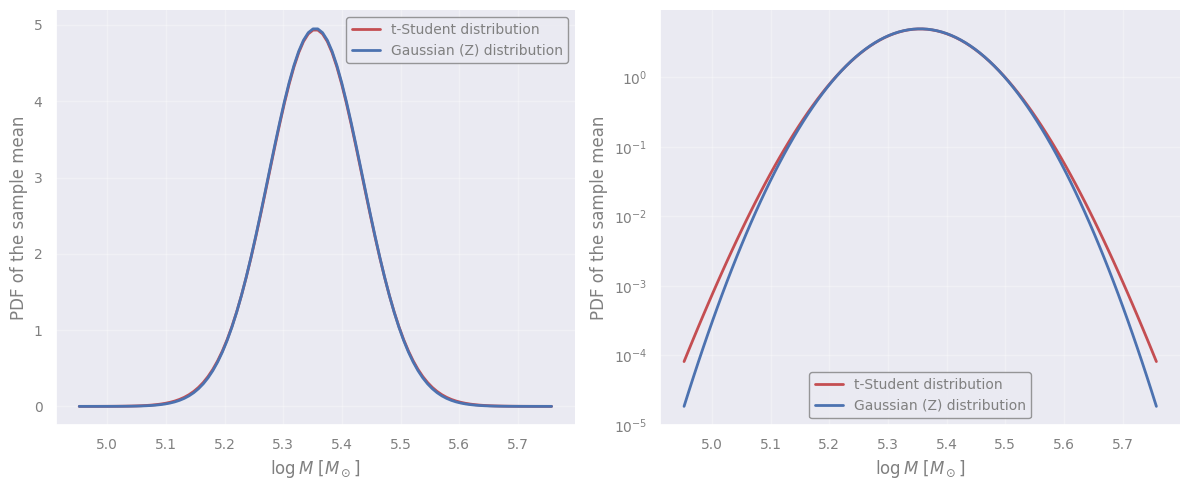

Sample t-score    :  -1.802
p-value           :  0.0753
    ...we cannot safely reject the null hypothesis. ****

Critical values   :  -1.990 and 1.990
    ...we cannot safely reject the null hypothesis. ****


In [16]:
x_plot = np.linspace(sample_mean - 5 * sample_sem, sample_mean + 5 * sample_sem, 100)

dof = len(log_masses) - 1   # the degrees of freedom
Z_dist = st.norm(loc=sample_mean, scale=sample_sem)
t_dist = st.t(dof, loc=sample_mean, scale=sample_sem)

plt.figure(figsize=(12, 5))
for inlog, subplot_index in zip([False, True], [1, 2]):
    plt.subplot(1, 2, subplot_index)
    plt.plot(x_plot, t_dist.pdf(x_plot), "r", label="t-Student distribution")
    plt.plot(x_plot, Z_dist.pdf(x_plot), "b", label="Gaussian (Z) distribution")
    plt.xlabel(r"$\log M\ [M_\odot]$")
    plt.ylabel("PDF of the sample mean")
    plt.legend(loc="best")
    if inlog:
        plt.yscale("log")
plt.show()

t_score = (sample_mean - model_mean) / sample_sem
p_value = 2 * st.t(dof).cdf(-abs(t_score))  # implied that loc=0, scale=1

print("Sample t-score    : {:7.3f}".format(t_score))
print("p-value           : {:7.3g}".format(p_value))

if p_value <  alpha:
    print("    ...we safely reject the null hypothesis. ****")
else:
    print("    ...we cannot safely reject the null hypothesis. ****")

print()

# alternatively we could compute the critical value and base our outcome on it
t_critical = abs(st.t(dof).ppf(alpha / 2.0))
print("Critical values   : {:7.3f} and {:.3f}".format(-t_critical, t_critical))
if abs(t_score) > abs(t_critical):
    print("    ...we safely reject the null hypothesis. ****")
else:
    print("    ...we cannot safely reject the null hypothesis. ****")


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: how and why did $p$ and critical values change compared to the $Z$-test?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

The $p$-value is smaller because the sample standard deviation is smaller than the model one, leading to smaller $\sigma/\sqrt{N}$. Consequently, the difference between the means is statistically more significant compared to the $Z$-test.

For the same significance level, the critical values of the $t$-statistic have larger absolute values than the $Z$-statistic because the $t$-Student distribution is broader. In principle, larger differences between the means are tolerated when we don't know the standard deviation.

The difference between the $Z$ and $t$ distributions in our example is small because we have a lot of data - it's way more important for really small samples.

</details>

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 1: Performing the $t$-student test directly</b></font>
    
**Task:**  Open the `scipy` documentation of the t-test function in https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html and complete the following code to perform the hypothesis testing.

</div>

In [ ]:
statistic, pvalue = st.ttest_1samp(..., ...)
print("Statistic = {:.3g}".format(statistic))
print("p-value   = {:.3g}".format(pvalue))

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
statistic, pvalue = st.ttest_1samp(log_masses, model_mean)
</pre>
  
</details>
</div>

# 4. The Central Limit Theorem

In the above example we assumed that the mean of the sample is normally-distributed, i.e. following the Gaussian distribution. This is often the case, at least with some approximation due to the **Central Limit Theorem**:

> The distribution of the sample mean approaches a normal distribution as the sample size gets larger, regardless of the actual shape of the underlying population distribution.

Let's take a distribution that has the shape of the *arcsine* function, which does not look like a Gaussian at all...

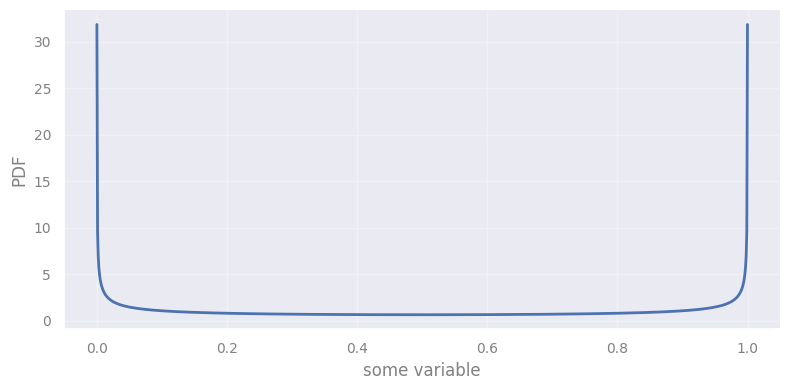

In [17]:
distribution = st.arcsine()
xx = np.linspace(0.0001, 1.0-0.0001, 1000)
plt.figure()
plt.plot(xx, distribution.pdf(xx))
plt.xlabel(r"some variable")
plt.ylabel("PDF")
plt.show()

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Hypothesis_Testing/images/thats-just-not-normal.jpg?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<p style="text-align: center; font-size: 0.9em; color: gray;">Figure 3. The Central Limit Theorem.</p>

Let's test the Central Limit Theorem by sampling the arcsine distribution using different sample sizes. We first plot how the first 3 samples and their means look like, and then we take a look at the distribution of those means after 10000 iterations.

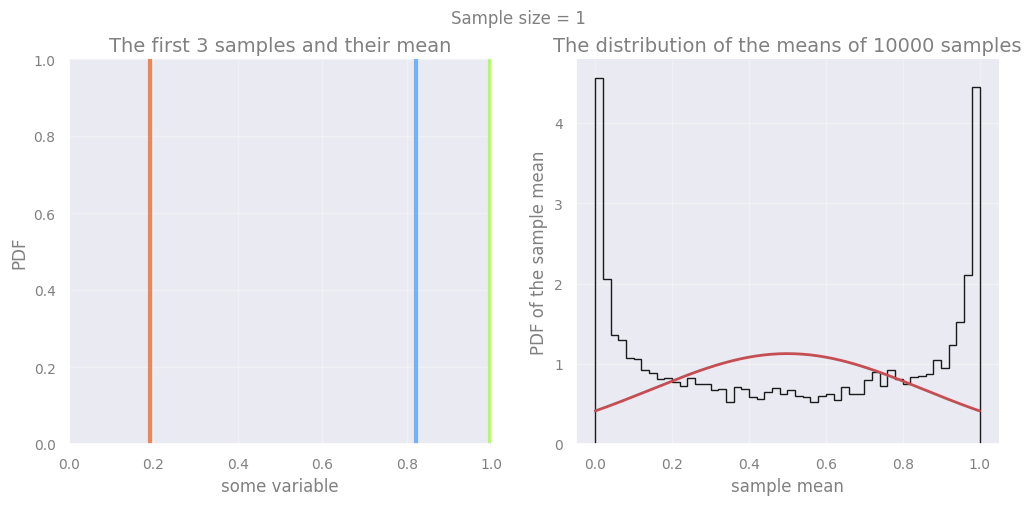

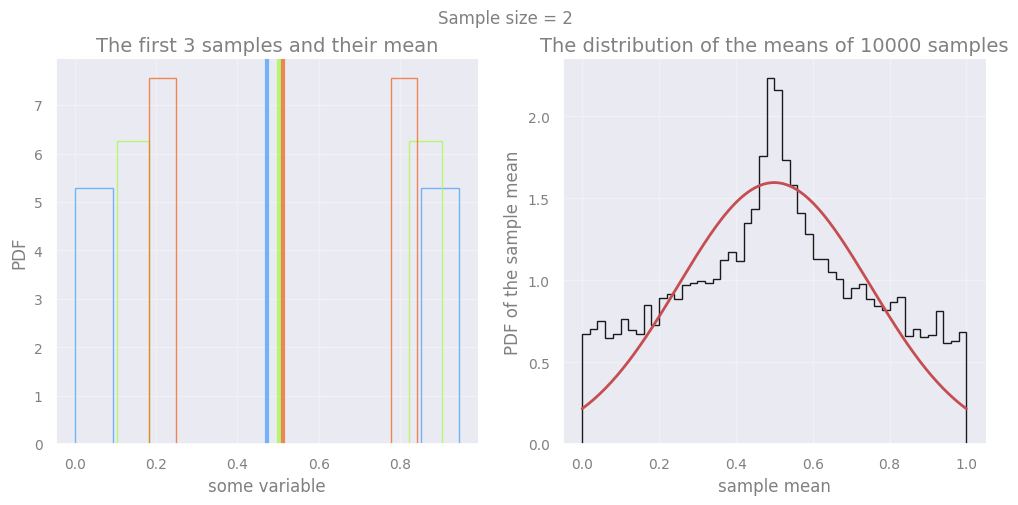

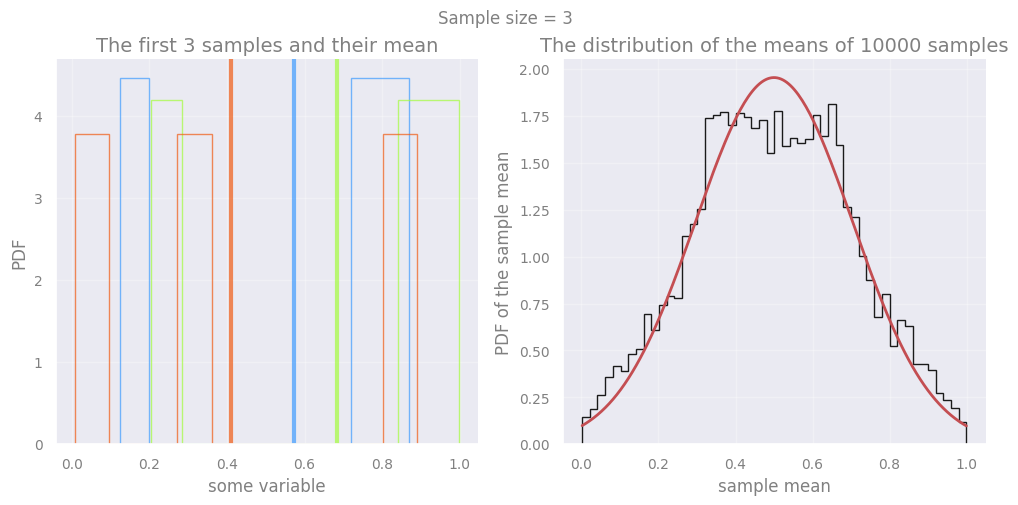

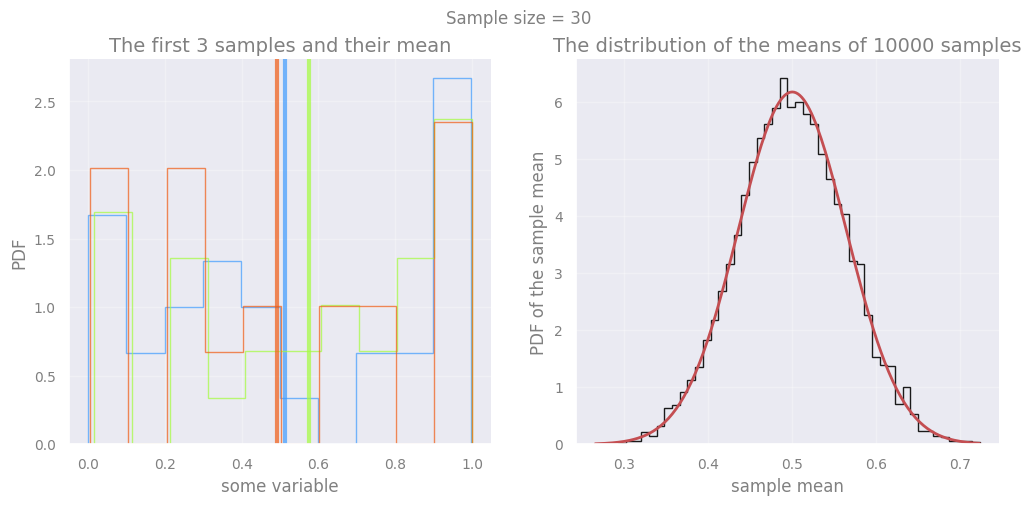

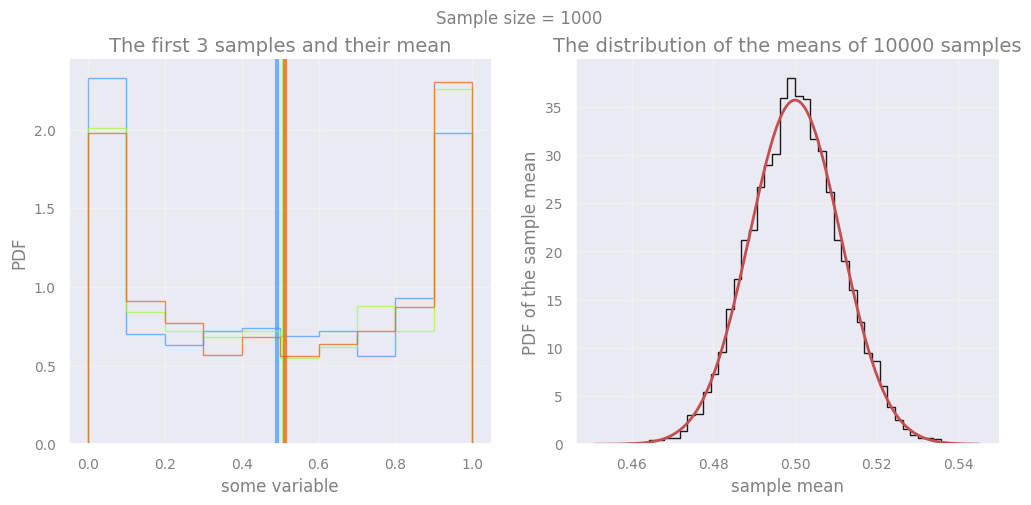

In [18]:
n_of_iterations = 10000
n_of_examples = 3
hist_colors = plt.colormaps.get_cmap("turbo")(np.linspace(0.2, 0.8, n_of_examples))
sample_sizes = [1, 2, 3, 30, 1000]

np.random.seed(31337)

for sample_size in sample_sizes:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=False)
    plt.suptitle(f"Sample size = {sample_size}")
    ax1.set_title(f"The first {n_of_examples} samples and their mean")
    ax1.set_xlabel("some variable")
    ax1.set_ylabel("PDF")
    ax2.set_title(f"The distribution of the means of {n_of_iterations} samples")

    sample_means = []
    for iteration in range(n_of_iterations):
        sample = distribution.rvs(size=sample_size)
        sample_mean = np.mean(sample)
        sample_means.append(sample_mean)

        if iteration < n_of_examples:
            if sample_size > 1:
                ax1.hist(sample, bins=10, density=True, histtype="step",
                         color=hist_colors[iteration], alpha=0.7, lw=1, label=f"Iteration {iteration+1}")
            ax1.axvline(sample_mean, color=hist_colors[iteration], lw=3, alpha=0.7)

    ax2.hist(sample_means, bins=50, histtype="step", density=True, color="k", lw=2)
    xx = np.linspace(min(sample_means), max(sample_means), 200)
    ax2.plot(xx, st.norm.pdf(xx, distribution.mean(), distribution.std() / sample_size**0.5), lw=2, color="r")
    plt.xlabel(r"sample mean")
    plt.ylabel("PDF of the sample mean")
    plt.show()

# 5. Distribution tests

## 5.1 Normality test

Above we used our eyes to see the validity of the Central Limit Theorem. But appearances (and plotting choices, e.g. bin sizes) can be deceiving! Luckily, we can quantitatively test whether a sample follows a known distribution.

In addition, we assumed that the data are normally distributed, which is an expectation from the theory, but this could be tested regardless of the parameters of the Gaussian distribution.

When our analysis depends on the "normality" of a distribution, it is better to perform a hypothesis test for exactly that - a **normality test**!

Here we use the **Shapiro-Wilk test for normality** (but it's not the only one out there) to test whether the log-masses of the GCs are following the normal distribution.

Remember that we **always have to ask what is the null hypothesis when using such tests**. For Shapiro-Wilk, the null hypothesis is:

>  $H_0$: the sample came from a normally distributed population

In [19]:
st.shapiro(log_masses)

ShapiroResult(statistic=np.float64(0.983459293667024), pvalue=np.float64(0.3818211827302129))

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: what do the above numbers mean?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Be careful when you are using such tests as a black box! Here, we have a well-defined null hypothesis but we have not set a significance level beforehand (step 2) and it is not clear what is the statistic being used (step 3). If we accept a general significance level of 5% then we should reject the hypothesis because the probability of it being wrong ("the date does not come from a normal distribution") is quite high ($\sim 40\%$). Look into the `scipy` documentation to find out the statistic: https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_shapiro.html#hypothesis-shapiro

</details>

</div>

## 5.2 Arbitrary distribution test: the K-S test

A normality test is very specific to the distribution we check against (Gaussian), but not its parameters. To check for agreement with any general distribution (but with a specific choice of parameters), the **Kolmogorov-Smirnov** test can be used.

> $H_0$: the sample is drawn from the reference distribution

The test is measuring the maximum distance between two cumulative distributions: one from the sample and another from the model (or another sample). This is called $D$ statistic and, depending on the sample size, it corresponds to a $p$-value. Let's see how it looks for our example, testing against the model distribution (which is a normal distribution anyway, but the KS test doesn't not care about it):

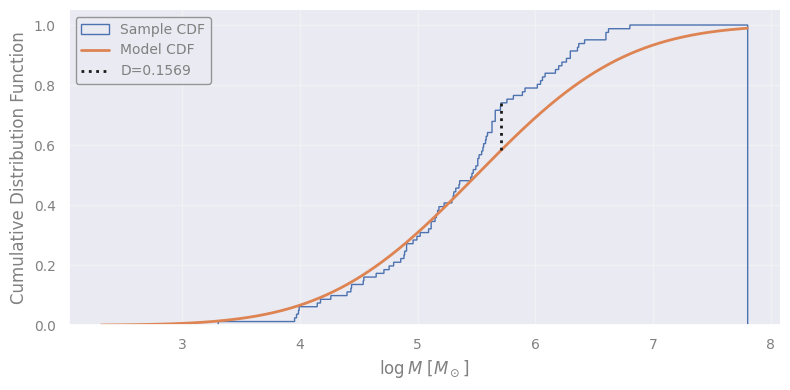

In [20]:
bins = np.linspace(min(log_masses)-1, max(log_masses)+1, 1000)
xx = (bins[1:] + bins[:-1]) / 2.0

model_cdf = st.norm.cdf(xx, loc=model_mean, scale=model_std)
plt.figure()
sample_cdf, _, _ = plt.hist(log_masses, bins=bins, density=True, cumulative=1,
                            histtype="step", label="Sample CDF")

# where is the maximum difference between the model and sample CDFs?
where_max_d = np.argmax(np.abs(model_cdf - sample_cdf))

# find the height of the CDFs at their furthest point
D1, D2 = model_cdf[where_max_d], sample_cdf[where_max_d]

# the maximum difference
D = abs(D1 - D2)

plt.plot(xx, model_cdf, label="Model CDF")
plt.plot([xx[where_max_d]]*2, [D1, D2], "k:", label="D={:.4g}".format(D))
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("Cumulative Distribution Function")
plt.legend(loc="upper left")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 2a: perform a Kolmogorov-Smirnoff test</b></font>
    
**Task:**  Test whether the log masses of the GCs follow the model's distribution. Use https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html to find out the syntax of the `scipy` function.

</div>

In [ ]:
# perform the K-S test
model_distribution = st.norm(model_mean, model_std)
st.kstest(..., ...)

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
st.ks_1samp(log_masses, model_distribution.cdf)
</pre>
  
</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: why do we get a different $p$-value with the K-S test, compared to the normality test?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

It's not that one method is incorrect. The questions are different, i.e., we tested different hypotheses!

With the Shapiro-Wilk test we tested if the data are normally distributed, whatever the mean and standard deviation. With the K-S test we tested if the data follow a very specific normal distribution with a defined mean and standard deviation.

</details>

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 2b: testing a distribution with its own sample</b></font>
    
**Task:**  Obviously, if we compare a sample's distribution with the true distribution, we expect (most of the times) agreement! Pick a sample size and run the K-S test.

</div>

In [ ]:
new_sample = model_distribution.rvs(size=...)
st.ks_1samp(new_sample, model_distribution.cdf)

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
new_sample = model_distribution.rvs(size=100)
</pre>
  
</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 2c: comparing two samples</b></font>
    
We can also use the K-S test to compare two different samples: are they coming from the same distribution?

Let's spicy things up and construct two distributions that are slightly different.

**Task:**  Select different sample sizes for each distribution. When does the test result in rejecting the hypothesis?

</div>

In [22]:
distribution1 = st.norm(0.0, 1.0)
distribution2 = st.norm(0.1, 0.98)
sample1 = distribution1.rvs(size=...)
sample2 = distribution2.rvs(size=...)

xmin_for_plotting = min(distribution1.ppf(0.001), distribution2.ppf(0.001))
xmax_for_plotting = max(distribution1.ppf(0.999), distribution2.ppf(0.999))
xx = np.linspace(xmin_for_plotting, xmax_for_plotting, 1000)
plt.figure()
plt.plot(xx, distribution1.pdf(xx), color="b", label="Distribution 1")
plt.plot(xx, distribution2.pdf(xx), color="g", label="Distribution 2")
plt.hist(sample1, bins="fd", histtype="step", color="b", alpha=0.5, density=True, label="Sample 1")
plt.hist(sample2, bins="fd", histtype="step", color="g", alpha=0.5, density=True, label="Sample 2")
plt.legend(loc="best")
plt.show()

st.ks_2samp(sample1, sample2)

TypeError: 'ellipsis' object cannot be interpreted as an integer

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
sample1 = distribution1.rvs(size=150)
sample2 = distribution2.rvs(size=200)
</pre>
  
</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: in the last exercise the distributions are different. How do you explain the effect of sample size?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

In hypothesis testing we never "accept" the null hypothesis - it was never wrong. We are just failing to reject the hypothesis because of lack of data!

</details>

</div>

# 6. Non-parametric hypothesis testing

What if there is no standard hypothesis test designed for our case? Or, what if the distribution of the statistic is hard to construct analytically?

No worries: If we can simulate data, we can use sampling methods to explore the expected values of the statistic we chose!

## 6.1 Example: is the maximum globular cluster mass consistent with the expectation from the model?

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: why would we use the statistic of `max` (or `min`) in astronomical data?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

It's typically difficult to measure faint objects: often we may observe only a few samples of the high-end of the distribution.
On the other hand, there are situations where the minimum is easier to be observed; for example, it's easier to detect exoplanets or binary stars with small orbital periods.

</details>

</div>

Hypothesis testing relies on the knowledge of the distribution of a statistic under the assumption that the **null hypothesis** holds. Here, we hypothesize that the sample follows the theoretical model.

The statistic can be anything, but note that the size of the sample is almost always important. The maximum log mass in our sample is $\sim 6.8$. Obviously, the larger the sample, the higher the chances to find higher maxima, so the sample size, 81, is important!

The question we need to answer becomes:

> Under the null hypothesis that the log mass of globular clusters follows a normal distribution $N(5.5, 1)$, is the maximum of 81 samples equal to 6.8?

### Simulating data
Since the **null hypothesis** is assumed to be correct, we need to create a sample of 81 GCs in a *parallel Universe* where the model holds (the log mass distribution).

### Computing the statistic

Using the simulated data, we can calculate any statistic following the same procedure as in the observational data. Here, it's simply taking the `max`.

### Constructing the "empirical PDF" of the statistic

We do the above multiple times (the more the better) to empirically construct the distribution of the statistic.

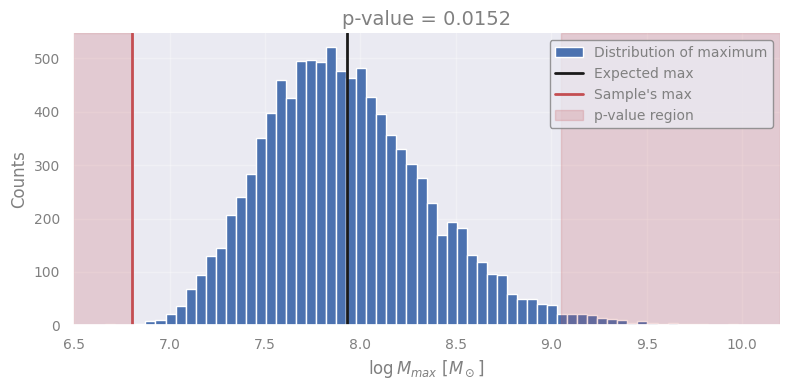

In [21]:
# EXPERIMENT #############################################################

# 1. Defining the null hypothesis (or the model)
model_distribution = st.norm(model_mean, model_std)

# 2. Defining the statistic (applied to observations, and simulated data)
def the_statistic(sample):
    return np.max(sample)

# 3. The number of iterations (simulations): the higher, the better
n_iterations = 10000

# 4. The size of the sample in each iteration (equal to the observed sample's size)
sample_size = len(log_masses)

# 5. Construct the statistic's distribution (following the model)
max_samples = np.array([the_statistic(model_distribution.rvs(size=sample_size)) for _ in range(n_iterations)])

# NOTE: we still haven't used the statistic's value in the sample!


# MESAURING THE P-VALUE ##################################################

# The observed maximum
sample_max = the_statistic(log_masses)

# Measuring how extreme the observed maximum is w.r.t. the model's distribution of the statistic
expected_max = np.mean(max_samples)
dist_from_expected_max = abs(expected_max - sample_max)
p_value = np.mean((max_samples < expected_max - dist_from_expected_max) | (max_samples > expected_max + dist_from_expected_max))

plt.figure()
plt.title(f"p-value = {p_value:.4f}")
plt.hist(max_samples, bins="fd", label="Distribution of maximum")
plt.axvline(expected_max, color="k", label="Expected max")
plt.axvline(sample_max, color="r", label="Sample's max")
xmin, xmax, ymin, ymax = plt.axis()
plt.axvspan(xmin, expected_max-dist_from_expected_max, color="r", alpha=0.2, label="p-value region")
plt.axvspan(expected_max+dist_from_expected_max, xmax, color="r", alpha=0.2)
plt.axis([xmin, xmax, ymin, ymax])
plt.legend(loc="best")
plt.xlabel(r"$\log M_{max}\ [M_\odot]$")
plt.ylabel("Counts")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: based on the $p$-value, what is our statement regarding the null hypothesis?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

We can reject the null hypothesis at the 5% significance level (assumed beforehand): "the log mass of globular clusters does not follow a normal distribution with $N(5.5, 1)$".
We have accepted a 5% chance of being wrong in rejecting the null hypothesis. We base our conclusion on the maximum mass observed (this is our statistic).

</details>

</div>

## 6.2 One-tail vs. two-tail tests

Notice that in all the above tests, we care about whether a specific value is extreme with respect to the mean value, without caring if it's less or greater!
But is this always the case?

### Example: detecting a source

In astronomical observations, we often aim to detect photons from sources in the presence of background noise (random photons).

Let's assume that in a region of $1$ arcsec$^2$ in our observed image the average background photon count is 10.3.

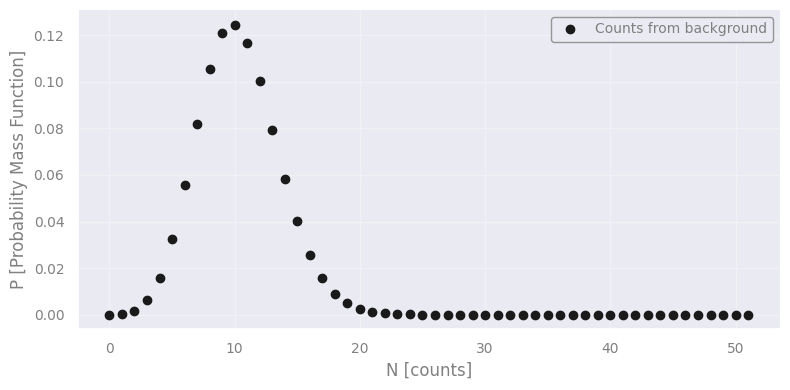

In [23]:
expected_background_counts = 10.3
counts = np.arange(0, np.ceil(expected_background_counts*5))

bkg_dist = st.poisson(expected_background_counts)
pmf = bkg_dist.pmf(counts)

plt.figure()
plt.plot(counts, pmf, "ko", label="Counts from background")
plt.legend(loc="upper right")
plt.xlabel(r"N [counts]")
plt.ylabel("P [Probability Mass Function]")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: would you say that there is a source if 30 counts were detected? What would be the null hypothesis?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

It seems like there is a source. The null hypothesis is: *"the detected 30 counts are coming from the background"*

</details>

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: would you say that there is a source if 0 counts were detected?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

It's well below the expected background. This cannot imply that there is a source because sources do not "negate" the background. Therefore it seems like the background was "lazy"! We can only infer the existence of a source if it exceeds the background by as much as required by our pre-defined significance level.

</details>

</div>

In [24]:
detected_counts = 30
significance_level = 0.001

p_value = 1.0 - bkg_dist.cdf(detected_counts)
print(f"p-value corresponding to more than {detected_counts} counts: {p_value:.4g}")

critical_value = bkg_dist.ppf(1.0 - significance_level)
print(f"Critical value for rejecting null hypothesis: {critical_value:.4g}")

# we can use either the p-value or the critical value here...
print(f"With significance level {significance_level:.4g} we", "reject" if p_value < significance_level else "cannot reject", "the null hypothesis (that these photons came from background noise).")

p-value corresponding to more than 30 counts: 1.498e-07
Critical value for rejecting null hypothesis: 22
With significance level 0.001 we reject the null hypothesis (that these photons came from background noise).


In [ ]:
# EOF